In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_squared_error

In [2]:
# 1. Chargement des données Bordeaux
bordeaux = pd.read_csv("../data/bordeaux_2022.csv")
bordeaux = bordeaux[bordeaux["Nombre pieces principales"] == 4]

# 2. Colonnes utiles
cols = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
]
bordeaux = bordeaux[cols]

In [3]:
# 3. Séparation Appartements / Maisons
bordeaux_apparts = bordeaux[bordeaux['Type local'].str.lower().str.contains('appartement')].copy()
bordeaux_maisons = bordeaux[bordeaux['Type local'].str.lower().str.contains('maison')].copy()

# 4. Nettoyage des données : terrain
median_terrain = bordeaux_maisons['Surface terrain'].median()
bordeaux_maisons['Surface terrain'] = bordeaux_maisons['Surface terrain'].fillna(median_terrain)
bordeaux_apparts['Surface terrain'] = bordeaux_apparts['Surface terrain'].fillna(0)

# 5. Prix au m²
bordeaux_maisons['prix_m2'] = bordeaux_maisons['Valeur fonciere'] / bordeaux_maisons['Surface reelle bati']
bordeaux_apparts['prix_m2'] = bordeaux_apparts['Valeur fonciere'] / bordeaux_apparts['Surface reelle bati']


In [4]:
# 6. Suppression des outliers (IQR)
def clean_outliers(df, columns):
    for col in columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df = df[(df[col] >= lb) & (df[col] <= ub)]
    return df

bordeaux_apparts = clean_outliers(bordeaux_apparts, ['prix_m2', 'Surface reelle bati'])
bordeaux_maisons = clean_outliers(bordeaux_maisons, ['prix_m2', 'Surface reelle bati', 'Surface terrain'])





In [5]:
# 8. Chargement des modèles entraînés sur Lille
model_appart = joblib.load("../models/appartement_xgboost.pkl")
model_maison = joblib.load("../models/maison_decision_tree.pkl")

feature_apparts=["Surface reelle bati", "Nombre de lots"] 
feature_maisons= ["Surface reelle bati", "Surface terrain"] 

# 9. Prédictions et MSE
X_appart = bordeaux_apparts[feature_apparts]
y_appart = bordeaux_apparts['prix_m2']
y_pred_appart = model_appart.predict(X_appart)
mse_appart = mean_squared_error(y_appart, y_pred_appart)

X_maison = bordeaux_maisons[feature_maisons]
y_maison = bordeaux_maisons['prix_m2']
y_pred_maison = model_maison.predict(X_maison)
mse_maison = mean_squared_error(y_maison, y_pred_maison)

# 10. Affichage des résultats
print("\n--- Résultats sur Bordeaux (Généralisation des modèles de Lille) ---")
print(f"MSE Appartements : {mse_appart:.2f}")
print(f"MSE Maisons      : {mse_maison:.2f}")


--- Résultats sur Bordeaux (Généralisation des modèles de Lille) ---
MSE Appartements : 2269733.11
MSE Maisons      : 8234776.70


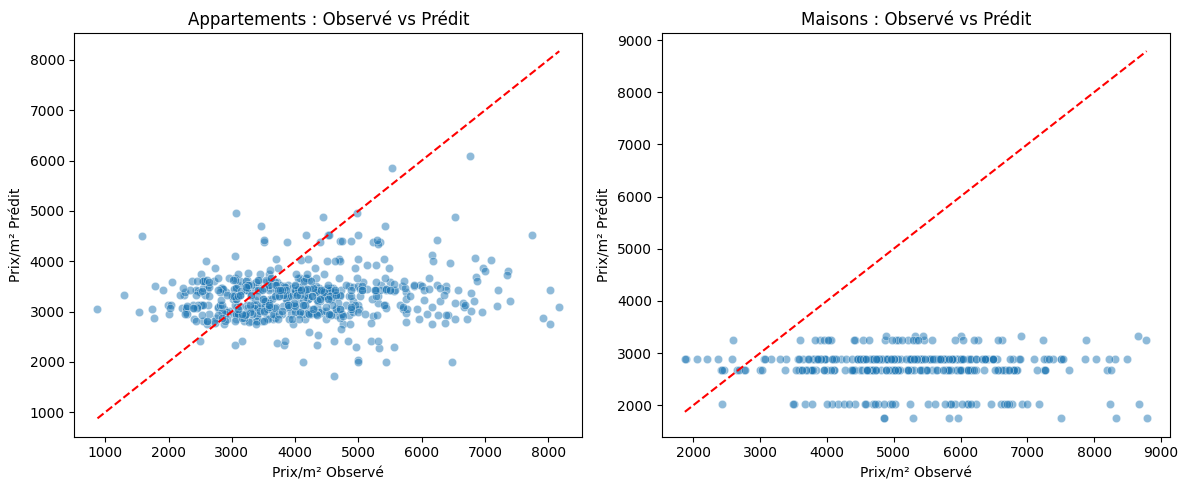

In [6]:
# 11. Visualisation des prédictions vs réels
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_appart, y=y_pred_appart, alpha=0.5)
plt.plot([y_appart.min(), y_appart.max()], [y_appart.min(), y_appart.max()], 'r--')
plt.title("Appartements : Observé vs Prédit")
plt.xlabel("Prix/m² Observé")
plt.ylabel("Prix/m² Prédit")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_maison, y=y_pred_maison, alpha=0.5)
plt.plot([y_maison.min(), y_maison.max()], [y_maison.min(), y_maison.max()], 'r--')
plt.title("Maisons : Observé vs Prédit")
plt.xlabel("Prix/m² Observé")
plt.ylabel("Prix/m² Prédit")

plt.tight_layout()
plt.show()